# Revenue forecasting on the Gold layer (weekly + monthly)

```
Bronze (sales csv) ─Silver_Notebook─▶ Silver.sales_silver ─Gold_Notebook─▶ Gold.factsales_gold + dims
                                                                                   │  this notebook
                                                                                   ▼
        Gold.revenue_forecast_gold   daily forecast (latest run)          Gold.revenue_weekly_gold    actual + forecast per ISO week
        Gold.forecast_backtest_gold  benchmark of every candidate model   Gold.revenue_monthly_gold   actual + forecast per month
        Gold.revenue_forecast_history_gold  monthly forecast of every run (append) for accuracy tracking
        MLflow experiment `sales_revenue_forecast` + registered model(s)
```

**Two ways to run it – both read the *live* lakehouse tables, nothing is copied**

| | How | What happens |
|---|---|---|
| **Fabric** (portal, pipeline, or VS Code with the *Fabric Data Engineering* extension and the **Microsoft Fabric Runtime** kernel) | `spark` is available → `RUN_MODE = "fabric-spark"` | aggregation runs in Spark, tables are written with `saveAsTable`, MLflow logs to the workspace experiment |
| **Local VS Code** (any Python kernel, no Spark) | `spark` is missing → `RUN_MODE = "local"` | reads `factsales_gold` straight from OneLake with `deltalake` + `azure-identity` (Delta protocol, always the latest committed version), writes the result tables back to OneLake, logs MLflow to Fabric through `synapseml-mlflow` (falls back to `./mlruns`) |

Local setup: `pip install -r requirements-local.txt`, sign in once with `az login` (or let the browser prompt appear), open this file in VS Code, pick your Python kernel and run all. Details in `README_VSCode.md`.

**What it does**
1. Builds the daily revenue series (`Quantity × UnitPrice + Tax`).
2. Benchmarks up to 25 candidate forecasters (11 single models + 14 blends; the XGBoost / CatBoost ones are skipped if the library is missing) with rolling-origin back-tests (train up to a month-end cutoff, forecast the next 3 months) and scores them on **weekly** and **monthly** totals: MAE, RMSE, MAPE, sMAPE, WAPE, Accuracy (= 100 − WAPE), bias, R², plus direction-of-change precision / recall / F1 and a confusion matrix (positive class = revenue up vs. the previous period).
3. Picks the champion (lowest average weekly sMAPE), retrains on all history, forecasts the rest of the current month + `HORIZON_MONTHS` full months.
4. Writes daily / weekly / monthly tables + the benchmark table, logs runs, metrics and models to MLflow.

**Pipeline note** – Prophet, XGBoost and CatBoost are not (all) in the default Fabric runtime. Interactively the first cell installs whatever is missing; for pipeline runs attach an *Environment* that contains `prophet`, `xgboost` and `catboost`, or add the notebook-activity parameter `_inlineInstallationEnabled = true` (Boolean). Locally, add `xgboost` and `catboost` to `requirements-local.txt`. If XGBoost / CatBoost cannot be installed the notebook still runs – those two candidates (and the blends that need them) are simply left out.


In [1]:
# Prophet, XGBoost and CatBoost are not (all) in the default Fabric runtime (statsmodels, scikit-learn, lightgbm, mlflow are included).
# KEEP THIS AS THE FIRST CELL: in Fabric, %pip restarts the Python interpreter -> one single %pip call for everything that is missing.
# Locally, install everything with: pip install -r requirements-local.txt (add xgboost and catboost to that file)
missing = []
for pkg in ("prophet", "xgboost", "catboost"):
    try:
        mod = __import__(pkg)
        print(f"{pkg} {mod.__version__} installed")
    except ImportError:
        missing.append(pkg)
if missing:
    print("installing:", ", ".join(missing))
    %pip install prophet xgboost catboost -q


c:\Users\hp\sales_predictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


prophet 1.4.0 installed
installing: xgboost, catboost
Note: you may need to restart the kernel to use updated packages.


In [2]:
#Config File

WORKSPACE_ID      = "1dca1c65-3ce2-483e-a7fb-baf7fca28e9f"   # used by local mode (OneLake path) and MLflow-to-Fabric
GOLD_LAKEHOUSE_ID = "a89b98b2-b7b2-477d-bc9c-9005e3b396aa"
LAKEHOUSE_NAME    = "Gold"
SCHEMA            = "dbo"

FACT_TABLE        = "factsales_gold"          # input  (Gold_Notebook)
FORECAST_TABLE    = "revenue_forecast_gold"   # output: daily forecast of the latest run
WEEKLY_TABLE      = "revenue_weekly_gold"     # output: actual + forecast revenue per ISO week
MONTHLY_TABLE     = "revenue_monthly_gold"    # output: actual + forecast revenue per month
BACKTEST_TABLE    = "forecast_backtest_gold"  # output: benchmark metrics per model / fold / grain
HISTORY_TABLE     = "revenue_forecast_history_gold"  # output: monthly forecast of EVERY run (append) -> track accuracy over time
KEEP_FORECAST_HISTORY = True

EXPERIMENT_NAME   = "sales_revenue_forecast"
REGISTERED_MODEL  = "sales_revenue_forecaster"   # pre-fix of the registered ML model item(s)

INCLUDE_TAX       = True    # Revenue = Quantity * UnitPrice + Tax
HORIZON_MONTHS    = 3       # forecast the rest of the current month + this many full months
BACKTEST_FOLDS    = 3       # rolling-origin folds (each = train to a month-end, forecast the next BACKTEST_HORIZON_MONTHS), how many times you perform a historical forecasting experiment.
BACKTEST_HORIZON_MONTHS = 3 # how far into the future each fold predicts which in this case is 3 months
INTERVAL_WIDTH    = 0.90    # prediction-interval width; 90% with +-10% errors/upper_lower bounds

# local (VS Code python kernel) only
LOCAL_MLFLOW_TO_FABRIC = True           # log locally by default; set True only after Fabric MLflow workspace access is granted
LOCAL_MLFLOW_FALLBACK  = "file:./mlruns" # used when the plugin is not installed


## 1. Connect to the Gold lakehouse (Fabric Spark or OneLake from your laptop)

In [3]:
import os, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

try:
    spark # exists in Fabric Spark sessions (portal, pipeline, VS Code "Microsoft Fabric Runtime" kernel)
    RUN_MODE = "fabric-spark"
except NameError:
    RUN_MODE = "local"
print("RUN_MODE =", RUN_MODE)

GOLD_TABLE_ROOT = f"abfss://{WORKSPACE_ID}@onelake.dfs.fabric.microsoft.com/{GOLD_LAKEHOUSE_ID}/Tables/{SCHEMA}"

def spark_table_name(table): #build table name
    return ".".join(p for p in (LAKEHOUSE_NAME, SCHEMA, table) if p)

def onelake_path(table): #build one_lake path
    return f"{GOLD_TABLE_ROOT}/{table}"

if RUN_MODE == "local":
    from deltalake import DeltaTable, write_deltalake

    def onelake_storage_options(): #authentication with oneLake
        if not GOLD_TABLE_ROOT.startswith("abfss://"):
            return {} #if url does not start with abfss, return empty dict
        from azure.identity import DefaultAzureCredential   # az login / VS Code sign-in / browser prompt
        cred = DefaultAzureCredential(exclude_interactive_browser_credential=False) #find everything for authentication, whatever is found, it can use it
        token = cred.get_token("https://storage.azure.com/.default").token #gives an access token that allows me to access Azure Storage.
        return {"bearer_token": token, "use_fabric_endpoint": "true"} #passes that authentication information to the Delta Lake library and gives access to ms fabric using fabric endpoint


def read_fact_daily():
    # Always queries the live Delta table (latest committed version) - nothing is cached or copied.
    if RUN_MODE == "fabric-spark":
        from pyspark.sql import functions as F
        fact = spark.read.table(spark_table_name(FACT_TABLE))
        revenue = F.col("Quantity") * F.col("UnitPrice") + (F.col("Tax") if INCLUDE_TAX else F.lit(0.0)) #making of column revenue, if INCLUDE_TAX is true then add tax else add 0.0
        pdf = (fact.filter(F.col("OrderDate").isNotNull())
                   .groupBy("OrderDate")
                   .agg(F.sum(revenue).alias("Revenue"),  #initialzing values in revenue column as sum of revenue and count of order lines
                        F.count("*").alias("OrderLines")) 
                   .orderBy("OrderDate")
                   .toPandas())
    else:
        dt = DeltaTable(onelake_path(FACT_TABLE), storage_options=onelake_storage_options())
        pdf = dt.to_pandas(columns=["OrderDate", "Quantity", "UnitPrice", "Tax"]).dropna(subset=["OrderDate"])
        pdf["Revenue"] = (pdf["Quantity"].astype(float) * pdf["UnitPrice"].astype(float)
                          + (pdf["Tax"].astype(float) if INCLUDE_TAX else 0.0))
        pdf = pdf.groupby("OrderDate").agg(Revenue=("Revenue", "sum"), 
                                           OrderLines=("Revenue", "size")).reset_index() #size = total row count without missing null values
    pdf["OrderDate"] = pd.to_datetime(pdf["OrderDate"])
    return pdf.sort_values("OrderDate").reset_index(drop=True)


def write_table(pdf, table, date_cols=(), mode="overwrite"):
    # Writes a pandas DataFrame to a Delta table in the Gold lakehouse (mode = "overwrite" or "append").
    pdf = pdf.copy()
    if RUN_MODE == "fabric-spark":
        from pyspark.sql import functions as F
        sdf = spark.createDataFrame(pdf)
        for c in date_cols:
            sdf = sdf.withColumn(c, F.to_date(c))
        writer = sdf.write.format("delta").mode(mode)
        writer = writer.option("overwriteSchema", "true") if mode == "overwrite" else writer.option("mergeSchema", "true")
        writer.saveAsTable(spark_table_name(table))
    else:
        for c in date_cols:
            pdf[c] = pd.to_datetime(pdf[c]).dt.date
        for c in pdf.columns:                                   # Delta stores microsecond timestamps
            if pd.api.types.is_datetime64_any_dtype(pdf[c]):
                pdf[c] = pdf[c].astype("datetime64[us, UTC]" if getattr(pdf[c].dt, "tz", None) is not None else "datetime64[us]")
        write_deltalake(onelake_path(table), pdf, mode=mode, schema_mode="overwrite" if mode == "overwrite" else "merge",
                        storage_options=onelake_storage_options())
    print(f"{'appended' if mode == 'append' else 'wrote'} {len(pdf):,} rows -> {table}")


RUN_MODE = local


In [4]:
# ---- MLflow tracking: Fabric experiment in both modes when possible ----
import mlflow

if RUN_MODE == "local":
    tracking = None #sabr rakhiye
    if LOCAL_MLFLOW_TO_FABRIC:
        try:
            from fabric.analytics.environment.credentials import SetFabricAnalyticsDefaultTokenCredentialsGlobally
            from azure.identity import DefaultAzureCredential
            SetFabricAnalyticsDefaultTokenCredentialsGlobally(
                credential=DefaultAzureCredential(exclude_interactive_browser_credential=False))
            tracking = f"sds://api.fabric.microsoft.com/v1/workspaces/{WORKSPACE_ID}/mlflow"
        except ImportError:
            print("synapseml-mlflow not installed -> logging to", LOCAL_MLFLOW_FALLBACK)
    if tracking is None:
        os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")
        tracking = LOCAL_MLFLOW_FALLBACK
    mlflow.set_tracking_uri(tracking)

# Connecting to Fabric does not prove the current identity can access its MLflow API.
# In a local kernel, preserve the forecast run by falling back when that API rejects us.
try:
    mlflow.set_experiment(EXPERIMENT_NAME)
except Exception as exc:
    if RUN_MODE != "local" or mlflow.get_tracking_uri() == LOCAL_MLFLOW_FALLBACK:
        raise
    print(f"Fabric MLflow unavailable ({exc}); logging locally to {LOCAL_MLFLOW_FALLBACK}")
    os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")
    mlflow.set_tracking_uri(LOCAL_MLFLOW_FALLBACK)
    mlflow.set_experiment(EXPERIMENT_NAME)
mlflow.autolog(disable=True)          # everything is logged explicitly (decided by developer i.e me)
print("MLflow tracking URI:", mlflow.get_tracking_uri())


2026-09-15 15:22:11 [INFO] setting mlflow tracking uri to sds://api.fabric.microsoft.com/v1/workspaces/1dca1c65-3ce2-483e-a7fb-baf7fca28e9f/mlflow, change this environment variable if you want log to other places
MLflow tracking URI: sds://api.fabric.microsoft.com/v1/workspaces/1dca1c65-3ce2-483e-a7fb-baf7fca28e9f/mlflow


## 2. Daily, weekly and monthly revenue history

In [5]:
#Stats/EDA

daily_pdf = read_fact_daily()
daily = (daily_pdf.set_index("OrderDate")["Revenue"].astype(float)
                  .sort_index() #continuous calendar, 0 on days without orders
                  .asfreq("D", fill_value=0.0)) #display every day and set null revenue values to 0.0         
START_DATE = daily.index.min()
LAST_DATE = daily.index.max()
is_month_end = LAST_DATE == LAST_DATE + pd.offsets.MonthEnd(0) #check weather the last date is month end or not, bool
FORECAST_START = LAST_DATE + pd.Timedelta(days=1)
FORECAST_END = LAST_DATE + pd.offsets.MonthEnd(HORIZON_MONTHS if is_month_end else HORIZON_MONTHS + 1) #this determines the months to be forcasted (future end date)
HORIZON_DAYS = int((FORECAST_END - LAST_DATE).days)

print(f"{len(daily)} days | {START_DATE.date()} -> {LAST_DATE.date()} | total revenue {daily.sum():,.0f}")
print(f"forecast window: {(LAST_DATE + pd.Timedelta(days=1)).date()} -> {FORECAST_END.date()} ({HORIZON_DAYS} days)\n")
print("Rows per year (if a year is missing, check date parsing in Silver_Notebook):")
print(daily_pdf.assign(Year=daily_pdf["OrderDate"].dt.year).groupby("Year")
               .agg(days_with_sales=("OrderDate", "nunique"), order_lines=("OrderLines", "sum"), revenue=("Revenue", "sum")).round(0)) #nunique = count distinct values for a specific column during a group-by operation, order_lines are number of rows



def to_periods(frame, grain): # resample the data to a different time period i.e weekly or monthly
    # frame: DataFrame indexed by day. Returns per-period sums + number of days covered, indexed by period start.
    rule = "W-SUN" if grain == "weekly" else "MS" # ISO weeks (Mon-Sun) / calendar months
    out = frame.resample(rule).sum() # sums the numerical columns i.e revenues
    out["Days"] = frame.iloc[:, 0].resample(rule).count() # counts how many rows (days) actually had data within each period and saves it in a new column called "Days"
    if grain == "weekly":
        out.index = out.index - pd.Timedelta(days=6)        # label by Monday
    out.index.name = "PeriodStart"
    return out

actual_weekly  = to_periods(daily.to_frame("ActualRevenue"), "weekly").rename(columns={"Days": "ActualDays"})
actual_monthly = to_periods(daily.to_frame("ActualRevenue"), "monthly").rename(columns={"Days": "ActualDays"})
print("\nLast 6 weeks (Mon-Sun):")
print(actual_weekly.tail(6).round(0))
print("\nLast 6 months:")
print(actual_monthly.tail(6).round(0))


915 days | 2019-07-01 -> 2021-12-31 | total revenue 22,602,264
forecast window: 2022-01-01 -> 2022-03-31 (90 days)

Rows per year (if a year is missing, check date parsing in Silver_Notebook):
      days_with_sales  order_lines     revenue
Year                                          
2019              184         1201   4172170.0
2020              365         2733   6882259.0
2021              365        28784  11547835.0

Last 6 weeks (Mon-Sun):
             ActualRevenue  ActualDays
PeriodStart                           
2021-11-22        397071.0           7
2021-11-29        336565.0           7
2021-12-06        343111.0           7
2021-12-13        298708.0           7
2021-12-20        351284.0           7
2021-12-27        245427.0           5

Last 6 months:
             ActualRevenue  ActualDays
PeriodStart                           
2021-07-01        915207.0          31
2021-08-01       1116929.0          31
2021-09-01       1141035.0          30
2021-10-01       1360836

## 3. Candidate models (with scaling where it matters)

| candidate | type | scaling |
|---|---|---|
| `naive_last_week`, `moving_avg_4w` | baselines | – |
| `holt_damped` | Holt's damped-trend exponential smoothing on weekly totals | scale-invariant |
| `prophet` | piecewise-linear trend with changepoints + yearly seasonality, daily data | scale-invariant (log-target was tested and hurt) |
| `ridge_lags` | Ridge regression on lagged weekly growth rates | **StandardScaler** inside the pipeline (required for a penalised linear model) + **log target** |
| `lightgbm_lags` | gradient-boosted trees on the same features | StandardScaler in the pipeline for consistency (trees are insensitive to it) + log target |
| `linreg_lags` | ordinary least squares on the same features (= Ridge without the penalty; the gap to `ridge_lags` shows what the L2 shrinkage buys) | StandardScaler + log target |
| `random_forest_lags` | bagged decision trees (300 trees, depth ≤ 3, ≥ 10 samples per leaf) | StandardScaler (no effect on trees) + log target |
| `gradboost_lags` | scikit-learn gradient boosting (100 depth-2 trees, learning rate 0.02, subsample 0.8) – a different implementation than LightGBM (exact splits, no histogram binning) | same |
| `xgboost_lags`, `catboost_lags` | XGBoost / CatBoost gradient boosting with the same budget as LightGBM (100 trees, depth 2, learning rate 0.02); skipped automatically if the library is not installed | same |
| `prophet_holt_blend`, `prophet_ridge_blend`, `prophet_holt_ridge_blend`, `prophet_rf_blend`, `prophet_gradboost_blend`, `prophet_lightgbm_blend`, `prophet_xgboost_blend`, `prophet_catboost_blend`, `holt_ridge_blend`, `boosting_blend`, `tree_blend`, `ml_blend`, `prophet_holt_boosting_blend`, `grand_blend` | plain averages of component forecasts (defined in `BLENDS`; a blend whose components are not all available is dropped) | – |

All tree models are kept deliberately shallow: each fold trains on only ~80–120 weekly rows, so deep trees or many boosting rounds would just memorise noise.

**Not included – Naive Bayes.** It is a *classifier*: GaussianNB / MultinomialNB output a class label from class-conditional densities, and scikit-learn has no regression variant. The target here (weekly log-growth → revenue) is continuous, so Naive Bayes cannot produce a revenue number and cannot be benchmarked against the models above. It could only be trained on a derived up/down label (see section 4), which would give a direction classifier, not a forecast.

The ML models predict weekly *log-growth* (`log(1+y_t) − log(1+y_{t−1})`) rather than the raw level: it makes the target stationary, lets the models extrapolate the 2021 growth, and removes the scale of revenue from the problem. Intervals for the baselines and ML models use the empirical spread of h-week-ahead changes in log revenue measured on the training window.

lower=forecast×e ^
(−Zσ)

upper=forecast×e ^
(Zσ)

In [ ]:
#models initialization and metrices

import logging
from scipy.stats import norm # to work with the normal (Gaussian) continuous probability distribution
from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing # statsmodels used to forecast future values in time series data by analyzing past levels, trends, and seasonal patterns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge # performs linear least squares regression with L2 regularization, which shrinks the model's coefficients to prevent overfitting. predicts future revenue growth using your historical growth features
from lightgbm import LGBMRegressor # used for tree based non linear model, later we will compare it with linear models
from sklearn.linear_model import LinearRegression # plain OLS = Ridge with alpha 0 (no shrinkage); comparing it with ridge_lags shows what the L2 penalty buys on ~100 rows
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor # bagged trees / scikit-learn's own gradient boosting (exact greedy splits, unlike LightGBM's histogram binning)
from sklearn.metrics import r2_score, precision_score, recall_score, f1_score, confusion_matrix # R2 for the regression, the rest for the direction-of-change classification (see score())
# XGBoost and CatBoost are optional: the first cell installs them, but if that is disabled (pipeline without inline installation) the notebook still runs without them.
try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None
    print("xgboost not installed -> xgboost_lags skipped")
try:
    from catboost import CatBoostRegressor
except ImportError:
    CatBoostRegressor = None
    print("catboost not installed -> catboost_lags skipped")

logging.getLogger("prophet").setLevel(logging.ERROR) # disable logs for prophet
logging.getLogger("cmdstanpy").disabled = True # disable logs for cmdstanpy

PROPHET_PARAMS = dict(growth="linear", #can be logistic, linear is sudden steepness while logistic is S-shaped curve (sigmoid function). It starts flat, goes through a period of sudden steepness, and then flattens out again at the top. It is used to predict probabilities (like yes/no outcomes). we use linear where we dont know upper or lower limits while we use logistic where there is some kind of physical constraint or saturation.
                      yearly_seasonality=True, #yearly trend enabled
                      weekly_seasonality=False,
                      daily_seasonality=False,
                      changepoint_prior_scale=0.5, #changepoint_prior_scale = Controls how flexible Prophet is when detecting changes in trend
                      changepoint_range=0.9, #changepoint_range = Prophet looks for trend changes during approximately the first 90% of the historical data (training data is 90%)
                      interval_width=INTERVAL_WIDTH) #interval_width = This tells Prophet how wide its uncertainty interval should be.
# Lagged growth only: level-vs-trend and calendar features were tested and hurt (they are learned from a single prior year).
# Remaining features are only mildly correlated (adjacent lags about -0.4, VIF <= 1.7).
ML_FEATURE_NAMES = ["growth_lag1", "growth_lag2", "growth_lag3", "growth_lag4", "growth_lag8"]


def weekly_bins(series):
    # complete 7-day bins ending on the last date of the series (used for modelling, not for reporting)
    anchor = "W-" + ["MON", "TUE", "WED", "THU", "FRI", "SAT", "SUN"][series.index[-1].dayofweek] #since i have data until 31 dec 2021, the anchor will be w-fri
    w = series.resample(anchor).sum()  #make weekly bins, sums on week basis
    if (w.index[0] - pd.Timedelta(days=6)) < series.index[0]: #ignore incomplete weeks (usually starting weeks)
        w = w.iloc[1:] #dry-run: 2019-07-05 - days = 2019-06-29; 2019-06-29 < 2019-07-01 (true); w will start from 2nd bin instead of 1st bin
    return w

def weekly_to_daily(point, lower, upper, start, horizon): #convert weekly predictions to daily predictions for daily forcasting
    idx = pd.date_range(start, periods=horizon, freq="D")
    spread = lambda x: np.repeat(np.asarray(x, float) / 7.0, 7)[:horizon] #flat prediction i.e if prediction is 700 then spread is 100, it means per day prediction is 100 (fake prediction), only to fill sales_revenue
    return pd.DataFrame({"yhat": spread(point), 
                         "yhat_lower": spread(lower), 
                         "yhat_upper": spread(upper)}, 
                         index=idx).clip(lower=0.0) #to avoid neg values

def horizon_log_std(weekly, max_h=52, min_obs=10): #Its job is to estimate: How uncertain is revenue when forecasting 1 week ahead, 2 weeks ahead, 3 weeks ahead, etc.? (skip)
    # empirical std of the h-week change in log revenue, h = 1..max_h (a random walk would grow like sqrt(h);
    # weekly totals are noisy but that noise is transient, so the measured growth is much slower)
    l = np.log1p(weekly)
    out = []
    for h in range(1, max_h + 1):
        d = (l.shift(-h) - l).dropna()
        out.append(float(d.std()) if len(d) >= min_obs else (out[-1] * np.sqrt(h / len(out)) if out else 0.3))
    return np.maximum.accumulate(np.array(out))# non-decreasing in h

Z = float(norm.ppf(1 - (1 - INTERVAL_WIDTH) / 2)) # Calculate Z-score, probability of specific number in standard normal distribution, no of sds from mean for a particular point, how usual and how unusal a data point is in df
def growth_band(point, hstd, horizon_weeks): #creates lower and upper prediction bounds.   
    s = np.resize(hstd, horizon_weeks) if horizon_weeks > len(hstd) else hstd[:horizon_weeks]
    return point * np.exp(-Z * s), point * np.exp(Z * s)


# ---- baselines --------------------------------------------------------------------------------
def make_naive(n_weeks): #The future will look like the most recent week.
    def fit(series):
        w = weekly_bins(series)
        return {"level": float(w.iloc[-n_weeks:].mean()), "hstd": horizon_log_std(w)} #(w.iloc[-n_week:]) last row and both columns, level = prediction, hstd = Historically, how much does weekly revenue change when looking 1 week ahead, 2 weeks ahead, 3 weeks ahead, etc.?
    def predict(model, start, horizon):
        n = int(np.ceil(horizon / 7)) #determination of weeks for weekly prediction through days
        point = np.repeat(model["level"], n) #actual prediction
        lo, hi = growth_band(point, model["hstd"], n) #lows and highs
        return weekly_to_daily(point, lo, hi, start, horizon)
    return fit, predict


# ---- Holt damped trend (weekly) -----------------------------------------------------------------
def fit_holt(series): #it learns from trend, rather than just picking last entities
    return ExponentialSmoothing(weekly_bins(series).values, 
                                trend="add",  #Model the trend additively i.e final_prediction = initial_predicition + Trend
                                damped_trend=True).fit(optimized=True) #the trend gradually becomes weaker as you forecast farther into the future and find best model parameters necessary

def predict_holt(model, start, horizon):
    n = int(np.ceil(horizon / 7)) #determination of weeks for weekly prediction through days
    point = np.clip(model.forecast(n), 0, None) #prediction, minimum value can be zero: if prediction is -ve, convert to zero, maximum can be unlimited
    sims = model.simulate(n, #weeks
                          repetitions=500, #500 possible scenerios to fetch point, upper, lower; range of 500 intervals
                          error="add", #additive error, it means add the noise too
                          random_state=42) #random seed
    lo = np.clip(np.quantile(sims, (1 - INTERVAL_WIDTH) / 2, axis=1), 0, None) #lows, qunatitle fetches the placement of value in entire interval
    hi = np.quantile(sims, 1 - (1 - INTERVAL_WIDTH) / 2, axis=1) #highs, same procedure just take the other value from lo
    return weekly_to_daily(point, lo, hi, start, horizon)


# ---- Prophet (daily) ------------------------------------------------------------------------------
def fit_prophet(series):
    m = Prophet(**PROPHET_PARAMS)
    m.fit(pd.DataFrame({"ds": series.index, "y": series.values}))
    return m

def predict_prophet(model, start, horizon):
    future = pd.DataFrame({"ds": pd.date_range(start, periods=horizon, freq="D")})
    return model.predict(future).set_index("ds")[["yhat", "yhat_lower", "yhat_upper"]].clip(lower=0.0)


# ---- feature-based ML models (weekly log-growth target, StandardScaler + estimator pipeline) ----------
def ml_features(logy):
    g = logy.diff() #current value - previous value, weekly log-growth, g = log1p(revenue_this_week) - log1p(revenue_last_week)
    X = pd.DataFrame(index=logy.index)
    for lag in (1, 2, 3, 4, 8): #creation of lags
        X[f"growth_lag{lag}"] = g.shift(lag)
    X["growth_mean4"] = g.shift(1).rolling(4).mean()
    X["growth_mean13"] = g.shift(1).rolling(13).mean()
    X["level_vs_13w"] = logy.shift(1) - logy.shift(1).rolling(13).mean()
    woy = X.index.isocalendar().week.astype(float).values #Week Of Year
    X["woy_sin"], X["woy_cos"] = np.sin(2 * np.pi * woy / 52.18), np.cos(2 * np.pi * woy / 52.18) #represents the cyclic nature of the calendar
    X["month"] = X.index.month
    return X[ML_FEATURE_NAMES], g

def make_ml(estimator_factory):
    def fit(series):
        logy = np.log1p(weekly_bins(series)) #calculate log-transformed weekly revenue as we are interested in relative growth, rather than raw revenue differences.
        X, g = ml_features(logy) #see above function
        mask = X.notna().all(axis=1) & g.notna() #Keep only rows where all required features and the target actually exist.
        pipe = Pipeline([("scale", StandardScaler()), ("model", estimator_factory())])
        pipe.fit(X[mask], g[mask])
        return {"pipe": pipe, "logy": logy, "hstd": horizon_log_std(np.expm1(logy))} #pipe = The trained Ridge/LightGBM model, logy = historical log revenue, hstd = Historical uncertainty information.
    def predict(model, start, horizon):
        logy, pipe = model["logy"].copy(), model["pipe"] #logy → historical log revenue; pipe → trained ML model
        n = int(np.ceil(horizon / 7)) #days to weeks, no. of weeks
        preds = []
        for _ in range(n):  # recursive multi-step, loops once for every future week and the prediction from one iteration becomes input for the next iteration.
            nxt = logy.index[-1] + pd.Timedelta(weeks=1) #stores next week to be predicted
            logy.loc[nxt] = np.nan #temp create storage for next prediction
            X, _ = ml_features(logy) # _ = discard the target labels
            logy.loc[nxt] = logy.iloc[-2] + float(pipe.predict(X.iloc[[-1]])[0]) #new log revenue = previous log revenue + predicted growth, why -2 bcz -1 has empty row ready to fill
            preds.append(logy.iloc[-1]) #add the predicted value
        point = np.expm1(np.array(preds)) # reverse of logy = np.log1p(revenue)
        lo, hi = growth_band(point, model["hstd"], n) #lows and highs of predicted value
        return weekly_to_daily(point, lo, hi, start, horizon)
    return fit, predict


# Every *_lags model shares make_ml: same 5 lagged-growth features, StandardScaler, weekly log-growth target, recursive multi-step forecast.
# Only the estimator differs, so the leaderboard compares the learners like-for-like. The training set is ~80-120 weekly rows per fold,
# hence the small tree budgets (depth 2-3, >=10 samples per leaf, 100 rounds at learning rate 0.02 = the LightGBM settings that were already here).
COMPONENTS = {
    "naive_last_week": make_naive(1),
    "moving_avg_4w":   make_naive(4),
    "holt_damped":     (fit_holt, predict_holt),
    "prophet":         (fit_prophet, predict_prophet),
    "linreg_lags":     make_ml(lambda: LinearRegression()),                               # ordinary least squares, no regularisation
    "ridge_lags":      make_ml(lambda: Ridge(alpha=1.0)),
    "random_forest_lags": make_ml(lambda: RandomForestRegressor(n_estimators=300,        # bagging: 300 bootstrapped trees, prediction = their average
                                                                max_depth=3,             # shallow trees -> smooth, low-variance growth estimates
                                                                min_samples_leaf=10,
                                                                random_state=42)),
    "gradboost_lags":  make_ml(lambda: GradientBoostingRegressor(n_estimators=100,       # scikit-learn boosting: each tree fits the residual of the previous ones
                                                                 learning_rate=0.02,
                                                                 max_depth=2,
                                                                 min_samples_leaf=10,
                                                                 subsample=0.8,          # stochastic gradient boosting: each tree sees 80% of the rows
                                                                 random_state=42)),
    "lightgbm_lags":   make_ml(lambda: LGBMRegressor(n_estimators=100, 
                                                     learning_rate=0.02, 
                                                     num_leaves=3,
                                                     min_child_samples=10, 
                                                     verbose=-1, 
                                                     random_state=42)),
}
if XGBRegressor is not None:
    COMPONENTS["xgboost_lags"] = make_ml(lambda: XGBRegressor(n_estimators=100,          # same budget as lightgbm_lags
                                                              learning_rate=0.02,
                                                              max_depth=2,
                                                              min_child_weight=10,       # = min samples per leaf for squared-error loss
                                                              subsample=0.8,
                                                              random_state=42,
                                                              verbosity=0))
if CatBoostRegressor is not None:
    COMPONENTS["catboost_lags"] = make_ml(lambda: CatBoostRegressor(iterations=100,      # same budget again; CatBoost grows symmetric (oblivious) trees
                                                                    learning_rate=0.02,
                                                                    depth=2,
                                                                    random_seed=42,
                                                                    verbose=0,
                                                                    allow_writing_files=False))  # no catboost_info/ folder on the driver / in the repo

# ---- blends = plain average of the components' daily forecasts (point, lower and upper) ----------------------------------
BLENDS = {
    "prophet_holt_blend":          ["prophet", "holt_damped"],
    "prophet_ridge_blend":         ["prophet", "ridge_lags"],
    "prophet_holt_ridge_blend":    ["prophet", "holt_damped", "ridge_lags"],
    # Prophet (trend + yearly seasonality) paired with each tree learner, like prophet_ridge_blend
    "prophet_rf_blend":            ["prophet", "random_forest_lags"],
    "prophet_gradboost_blend":     ["prophet", "gradboost_lags"],
    "prophet_lightgbm_blend":      ["prophet", "lightgbm_lags"],
    "prophet_xgboost_blend":       ["prophet", "xgboost_lags"],
    "prophet_catboost_blend":      ["prophet", "catboost_lags"],
    "holt_ridge_blend":            ["holt_damped", "ridge_lags"],
    # families
    "boosting_blend":              ["gradboost_lags", "lightgbm_lags", "xgboost_lags", "catboost_lags"],              # the four gradient boosters
    "tree_blend":                  ["random_forest_lags", "gradboost_lags", "lightgbm_lags", "xgboost_lags", "catboost_lags"],
    "ml_blend":                    ["linreg_lags", "ridge_lags", "random_forest_lags", "gradboost_lags", "lightgbm_lags", "xgboost_lags", "catboost_lags"],
    "prophet_holt_boosting_blend": ["prophet", "holt_damped", "lightgbm_lags", "xgboost_lags", "catboost_lags"],
    "grand_blend":                 ["prophet", "holt_damped", "ridge_lags", "random_forest_lags", "gradboost_lags", "lightgbm_lags", "xgboost_lags", "catboost_lags"],  # everything except the baselines
}
CANDIDATES = {name: [name] for name in COMPONENTS}   # every single model is a candidate ...
for name, comps in BLENDS.items():                    # ... plus every blend whose components are available
    comps = [c for c in comps if c in COMPONENTS]     # drop xgboost/catboost if their library is missing
    if len(comps) >= 2:
        CANDIDATES[name] = comps
print(f"{len(COMPONENTS)} components + {len(CANDIDATES) - len(COMPONENTS)} blends = {len(CANDIDATES)} candidates")

def blend(component_preds, names): #component_preds = predictions from models, names = names of models to be blended together
    return sum(component_preds[n] for n in names) / len(names) # predicted value1 + predicted value2 + ... n / n


def score(actual, forecast, prev=None):
    # actual/forecast: per-period revenue over the back-test horizon (weekly bins or months).
    # prev: revenue of the period right BEFORE the first one (last training week/month) -> gives period 1 a reference for the direction metrics.
    a, f = np.asarray(actual, float), np.asarray(forecast, float) #a = actual, f = forecasted/predicted
    err = f - a #difference
    wape = 100 * np.sum(np.abs(err)) / max(np.sum(np.abs(a)), 1e-9) #Weighted 'Absolute Percentage Error', totaL error percentage, 1e-9 prevents division by zero, sum of abs errors/sum of actuals
    out = {"MAE":  float(np.mean(np.abs(err))), #mean 'absolute error'
           "RMSE": float(np.sqrt(np.mean(err ** 2))), #root mean 'squared error'
           "MAPE": float(100 * np.mean(np.abs(err) / np.maximum(np.abs(a), 1e-9))), #mean 'abosulte percentage error'
           "sMAPE": float(100 * np.mean(2 * np.abs(err) / np.maximum(np.abs(a) + np.abs(f), 1e-9))), #Symmetric Mean Absolute Percentage Error, 
           "WAPE": float(wape),
           "AccuracyPct": float(max(0.0, 100 - wape)), #accuracy percentage, The baseline business health score.
           "BiasPct": float(100 * np.sum(err) / max(np.sum(a), 1e-9))} #bias percentage, Directional skew. Are we over-predicting or under-predicting in total?

    # R2 = 1 - SSE/SST: share of the period-to-period variance of the actuals that the forecast explains. 1 = perfect, 0 = no better than
    # predicting the horizon's own mean, negative = worse than that. Needs >= 2 periods; with only 3 monthly points per fold it is unstable, read the weekly value.
    out["R2"] = float(r2_score(a, f)) if len(a) >= 2 and np.ptp(a) > 0 else float("nan")

    # ---- classification view: precision / recall / F1 / confusion matrix need a class label, and a revenue forecast has none. ----
    # The one binary event a forecast implies is the DIRECTION of change: did revenue go UP versus the previous period (positive class) or not?
    # Comparing the model's predicted direction with what really happened tells whether it gets the turning points right, regardless of the size of the error.
    # A flat weekly forecast (naive, moving average) can only call "up" for period 1 (its level vs. the last training week); after that it never
    # predicts a rise, so its weekly precision/recall/F1 are ~0 by construction. At the monthly grain the month lengths (28/30/31 days) give it a spurious direction.
    if prev is not None:
        a_up = np.r_[a[0] > prev, a[1:] > a[:-1]]   # what actually happened, period by period
        f_up = np.r_[f[0] > prev, f[1:] > f[:-1]]   # what the model said would happen
        tn, fp, fn, tp = confusion_matrix(a_up, f_up, labels=[False, True]).ravel()
        out.update({"DirAccuracyPct": float(100 * (tp + tn) / len(a)),                    # share of periods whose direction was called correctly
                    "DirPrecision": float(precision_score(a_up, f_up, zero_division=0)),   # of the periods the model called "up", how many really went up
                    "DirRecall":    float(recall_score(a_up, f_up, zero_division=0)),      # of the periods that really went up, how many the model caught
                    "DirF1":        float(f1_score(a_up, f_up, zero_division=0)),          # harmonic mean of precision and recall
                    "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn)})           # the 2x2 confusion matrix, one cell per column (summed over folds later)
    else:
        out.update({"DirAccuracyPct": float("nan"), "DirPrecision": float("nan"), "DirRecall": float("nan"), "DirF1": float("nan"),
                    "TP": 0, "FP": 0, "TN": 0, "FN": 0})
    return out


11 components + 14 blends = 25 candidates


## 4. Benchmark: rolling-origin back-test on weekly and monthly totals
Each fold trains on everything up to a month-end cutoff and forecasts the next 3 calendar months; the folds are the last three quarters of history. The champion is the lowest average **weekly sMAPE** (weekly has ~13 points per fold, monthly only 3, so it is the more stable criterion).

Besides the error metrics, every model / fold / grain row also gets:
* **R2** – variance of the actual periods explained by the forecast (can be negative = worse than the horizon's own mean). Meaningful at the weekly grain; the monthly value rests on 3 points per fold.
* **Direction-of-change classification metrics** – precision, recall, F1 and a confusion matrix need a class label, and a revenue forecast has none, so they are computed on the one binary event a forecast implies: *revenue higher than the previous period* (positive class = UP). `DirAccuracyPct`, `DirPrecision`, `DirRecall`, `DirF1` are averaged over the folds like the other metrics; the confusion-matrix cells `TP / FP / TN / FN` are stored per row in `forecast_backtest_gold` and **summed** over the folds for the pooled matrices printed below. Flat weekly forecasts (naive, moving average) can only call UP for the first period, so their weekly precision / recall / F1 are ~0 by construction (at the monthly grain the 28/30/31-day month lengths give them a spurious direction). Note that R² on a short horizon is judged against the horizon's *own* mean – information no forecaster has – so negative values are common even for good models; that is why the error metrics, not R², rank the candidates.

The champion is still picked on weekly sMAPE – the direction metrics describe *whether the turns are called right*, not how big the error is.

In [7]:
#helps in making revenue_forecast_history_gold and comparing models to get best model for our data.

import time

eval_end = LAST_DATE if is_month_end else LAST_DATE + pd.offsets.MonthEnd(-1) #calculates last date of the month, if last date is not month end then it will go to previous month end
cutoffs = [eval_end + pd.offsets.MonthEnd(-BACKTEST_HORIZON_MONTHS * k) for k in range(BACKTEST_FOLDS, 0, -1)] # creates a list of cutoff dates/ folds for backtesting, helps in knowing how many months to go back for backtesting, if BACKTEST_FOLDS = 3 and BACKTEST_HORIZON_MONTHS = 3 then it will create 3 cutoffs for 3 folds, each fold will be 3 months apart

'''
cutoffs =
[
    2021-03-31,
    2021-06-30,
    2021-09-30
]
'''

rows = []
for fold, cutoff in enumerate(cutoffs, start=1):
    horizon_end = cutoff + pd.offsets.MonthEnd(BACKTEST_HORIZON_MONTHS) # calculates the end date of the forecast horizon i.e if cutoff is 2021-03-31 and BACKTEST_HORIZON_MONTHS = 3 then horizon_end will be 2021-06-30
    train  = daily[:cutoff] #training data is all the data up to the cutoff date
    actual = daily[cutoff + pd.Timedelta(days=1): horizon_end] #actual data is all the data from the day after the cutoff date to the end of the forecast horizon
    start  = cutoff + pd.Timedelta(days=1) # the start date of the forecast horizon is the day after the cutoff date
 
    preds = {} # it will store the predictions from each component model for the current fold
    for comp, (fit_fn, predict_fn) in COMPONENTS.items(): #the 2nd parameter of for loop is a tuple of (fit_fn, predict_fn) for each component model that is defined in the COMPONENTS dictionary. fit_fn is the function that fits the model to the training data, and predict_fn is the function that makes predictions using the fitted model.
        t0 = time.time() # start time for measuring how long it takes to fit and predict for the current component model
        preds[comp] = predict_fn(fit_fn(train), start, len(actual)) 
        print(f"fold {fold} | train to {cutoff.date()} | {comp:<16} {time.time() - t0:5.1f}s") #print the fold number, cutoff date, component model name, and the time taken to fit and predict for the current component model

    actual_w, actual_m = weekly_bins(actual), actual.resample("MS").sum() #actual_w = actual data resampled to weekly bins, actual_m = actual data resampled to monthly bins, So now we can evaluate forecasts at two different grains
    # revenue of the period right before the first evaluated period = reference for the direction (up/down) of period 1 (weekly bins are labelled by their last day)
    prev_w = float(daily.loc[actual_w.index[0] - pd.Timedelta(days=13): actual_w.index[0] - pd.Timedelta(days=7)].sum())  # the 7 days before the first complete weekly bin
    prev_m = float(daily.loc[cutoff + pd.offsets.MonthBegin(-1): cutoff].sum())                                            # the cutoff month (last training month)
    for cand, comps in CANDIDATES.items(): #from 'CANDIDATES'.
        fc = blend(preds, comps)["yhat"] #blend the predictions from the component models for the current candidate model, and store the blended predictions in fc
        for grain, a, f, prev in (("weekly", actual_w, weekly_bins(fc), prev_w), ("monthly", actual_m, fc.resample("MS").sum(), prev_m)):
            rows.append({"Model": cand, "Fold": fold, "CutoffDate": cutoff.date(), "HorizonEnd": horizon_end.date(),
                         "Grain": grain, "Periods": len(a), **score(a.values, f.values, prev=prev)})

backtest = pd.DataFrame(rows)
ERROR_METRICS     = ["MAE", "RMSE", "MAPE", "sMAPE", "WAPE", "AccuracyPct", "BiasPct"]
DIRECTION_METRICS = ["R2", "DirAccuracyPct", "DirPrecision", "DirRecall", "DirF1"]   # averaged over folds like the error metrics
CM_CELLS          = ["TP", "FP", "TN", "FN"]                                          # confusion-matrix cells: summed over folds (counts, not rates)
METRICS = ERROR_METRICS + DIRECTION_METRICS
leaderboard = (backtest.groupby(["Grain", "Model"])[METRICS].mean()
                       .unstack("Grain").swaplevel(axis=1).sort_index(axis=1))
leaderboard = leaderboard.sort_values(("weekly", "sMAPE"))   # champion criterion unchanged: weekly sMAPE
confusion = backtest.groupby(["Grain", "Model"])[CM_CELLS].sum()   # pooled 2x2 confusion matrix per model and grain
CHAMPION = leaderboard.index[0]
backtest["IsChampion"] = backtest["Model"].eq(CHAMPION)

def confusion_table(model, grain):
    # the pooled confusion matrix as a 2x2 table: rows = what actually happened, columns = what the model predicted
    c = confusion.loc[(grain, model)]
    return pd.DataFrame([[c["TP"], c["FN"]], [c["FP"], c["TN"]]],
                        index=["actual UP", "actual DOWN"], columns=["predicted UP", "predicted DOWN"])

pd.set_option("display.width", 220)
for grain in ("weekly", "monthly"):
    print(f"\n=== Benchmark: average over folds ({grain} grain) ===")
    print(leaderboard[grain][ERROR_METRICS].round(1).to_string())
    print(f"\n=== R2 + direction-of-change classification, {grain} grain (positive class = revenue UP vs previous {grain[:-2]}; TP/FP/TN/FN pooled over {BACKTEST_FOLDS} folds) ===")
    print(leaderboard[grain][DIRECTION_METRICS].round(2).join(confusion.loc[grain]).to_string())
print(f"\nChampion: {CHAMPION}")
for grain in ("weekly", "monthly"):
    print(f"\nConfusion matrix of the champion, {grain} grain, {BACKTEST_FOLDS} folds pooled:")
    print(confusion_table(CHAMPION, grain).to_string())

# one MLflow run per candidate so the benchmark is visible in the experiment
for cand, comps in CANDIDATES.items():
    with mlflow.start_run(run_name=f"backtest_{cand}"):
        mlflow.log_params({"model": cand, "components": "+".join(comps), "backtest_folds": BACKTEST_FOLDS,
                           "backtest_horizon_months": BACKTEST_HORIZON_MONTHS, "include_tax": INCLUDE_TAX,
                           **({f"prophet_{k}": v for k, v in PROPHET_PARAMS.items()} if "prophet" in comps else {}),
                           **({"features": ",".join(ML_FEATURE_NAMES), "scaler": "StandardScaler", "target": "weekly log-growth"}
                              if any(c.endswith("_lags") for c in comps) else {})})
        for grain in ("weekly", "monthly"):
            mlflow.log_metrics({f"{grain}_{m}": float(v) for m, v in leaderboard.loc[cand, grain].items() if pd.notna(v)})   # R2 can be NaN
            mlflow.log_metrics({f"{grain}_{c}": float(v) for c, v in confusion.loc[(grain, cand)].items()})                   # pooled TP/FP/TN/FN
            for _, r in backtest[(backtest["Model"] == cand) & (backtest["Grain"] == grain)].iterrows():
                mlflow.log_metrics({f"fold_{grain}_sMAPE": r["sMAPE"], f"fold_{grain}_AccuracyPct": r["AccuracyPct"],
                                    **({f"fold_{grain}_R2": r["R2"]} if pd.notna(r["R2"]) else {}), f"fold_{grain}_DirF1": r["DirF1"]}, step=int(r["Fold"]))
        mlflow.set_tag("champion", str(cand == CHAMPION))


fold 1 | train to 2021-03-31 | naive_last_week    0.1s
fold 1 | train to 2021-03-31 | moving_avg_4w      0.0s
fold 1 | train to 2021-03-31 | holt_damped        0.1s
fold 1 | train to 2021-03-31 | prophet            2.4s
fold 1 | train to 2021-03-31 | linreg_lags        0.7s
fold 1 | train to 2021-03-31 | ridge_lags         0.4s
fold 1 | train to 2021-03-31 | random_forest_lags   2.4s
fold 1 | train to 2021-03-31 | gradboost_lags     0.7s
fold 1 | train to 2021-03-31 | lightgbm_lags      0.3s
fold 1 | train to 2021-03-31 | xgboost_lags       0.7s
fold 1 | train to 2021-03-31 | catboost_lags      1.0s
fold 2 | train to 2021-06-30 | naive_last_week    0.0s
fold 2 | train to 2021-06-30 | moving_avg_4w      0.0s
fold 2 | train to 2021-06-30 | holt_damped        0.1s
fold 2 | train to 2021-06-30 | prophet            0.7s
fold 2 | train to 2021-06-30 | linreg_lags        0.4s
fold 2 | train to 2021-06-30 | ridge_lags         0.4s
fold 2 | train to 2021-06-30 | random_forest_lags   1.8s
fold 2

Last date = 31-december-2021
is_month_end = true
backtest_folds = 3
horizon_months = 3

eval_end = 31-12-2021
cutoffs = march 31, 2021 (-9 months); june 30, 2021 (-6 months); september 30, 2021 (-3 months)

1st iteration: fold = 1; cutoff = 2021-march-31; horizon_end = 2021-june-30; train = from july 1 2019 to 2021 march 31; actual = 2021-april-01 → 2021-june-30 (for testing); start = 2021 april 01

## 5. Retrain the champion on all history → daily, weekly and monthly forecast

In [8]:
from datetime import datetime, timezone

RUN_TS = datetime.now(timezone.utc)
FORECAST_START = LAST_DATE + pd.Timedelta(days=1)

def log_component_model(comp, model):
    try: #log the component model to MLflow, if it is a model that can be logged
        name = f"{REGISTERED_MODEL}_{comp}"  #create registered model name by combining the base registered model prefix with the component name
        if comp == "prophet":
            mlflow.prophet.log_model(model, artifact_path=comp, registered_model_name=name)
        elif comp == "holt_damped":
            mlflow.statsmodels.log_model(model, artifact_path=comp, registered_model_name=name)
        elif comp.endswith("_lags"):
            # cloudpickle explicitly: MLflow >= 3 defaults the sklearn flavour to skops, which refuses "untrusted" classes such as
            # XGBRegressor / CatBoostRegressor inside the pipeline (older MLflow, e.g. the Fabric runtime, already defaults to cloudpickle)
            mlflow.sklearn.log_model(model["pipe"], artifact_path=comp, registered_model_name=name,
                                     serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE)
        else:
            mlflow.log_dict({"level": model["level"]}, f"{comp}.json")
    except Exception as e:      # a flavour problem must not fail the pipeline
        print(f"WARNING: could not log {comp} to MLflow: {e}")

with mlflow.start_run(run_name=f"champion_{CHAMPION}") as run: # purpose: to log the champion model and its predictions to MLflow, so that we can track the performance of the best model over time and compare it with other models in the future.
    fitted, preds = {}, {}
    for comp in CANDIDATES[CHAMPION]:
        fit_fn, predict_fn = COMPONENTS[comp]
        fitted[comp] = fit_fn(daily) #train on all data.
        preds[comp]  = predict_fn(fitted[comp], FORECAST_START, HORIZON_DAYS)
    fc = blend(preds, CANDIDATES[CHAMPION]).rename(columns={"yhat": "ForecastRevenue", "yhat_lower": "ForecastLower", "yhat_upper": "ForecastUpper"})

    # daily table
    forecast_daily = fc.reset_index().rename(columns={"index": "ForecastDate", "ds": "ForecastDate"})
    forecast_daily.insert(1, "HorizonDay", np.arange(1, HORIZON_DAYS + 1))
    forecast_daily["Year"], forecast_daily["Month"] = forecast_daily["ForecastDate"].dt.year, forecast_daily["ForecastDate"].dt.month
    forecast_daily["yyyymm"]  = forecast_daily["ForecastDate"].dt.strftime("%Y%m")
    forecast_daily["mmmyyyy"] = forecast_daily["ForecastDate"].dt.strftime("%b-%Y")

    # weekly / monthly tables = actual history + forecast, one row per period (a period can hold both if it straddles LAST_DATE)
    def combined(grain):
        f = to_periods(fc, grain).rename(columns={"Days": "ForecastDays"})
        out = actual_weekly.join(f, how="outer") if grain == "weekly" else actual_monthly.join(f, how="outer")
        out = out.fillna({"ActualRevenue": 0.0, "ActualDays": 0, "ForecastRevenue": 0.0, "ForecastLower": 0.0, "ForecastUpper": 0.0, "ForecastDays": 0})
        out["ActualDays"], out["ForecastDays"] = out["ActualDays"].astype(int), out["ForecastDays"].astype(int)
        out = out.reset_index()
        if grain == "weekly":
            out["PeriodEnd"] = out["PeriodStart"] + pd.Timedelta(days=6)
            iso = out["PeriodStart"].dt.isocalendar()
            out["IsoYear"], out["IsoWeek"] = iso["year"].astype(int), iso["week"].astype(int)
            out["YearWeek"] = out["IsoYear"].astype(str) + "-W" + out["IsoWeek"].astype(str).str.zfill(2)
        else:
            out["PeriodEnd"] = out["PeriodStart"] + pd.offsets.MonthEnd(0)
            out["Year"], out["Month"] = out["PeriodStart"].dt.year, out["PeriodStart"].dt.month
            out["yyyymm"], out["mmmyyyy"] = out["PeriodStart"].dt.strftime("%Y%m"), out["PeriodStart"].dt.strftime("%b-%Y")
        out["TotalRevenue"] = out["ActualRevenue"] + out["ForecastRevenue"]          # continuous series for charts
        out["RecordType"] = np.select([out["ForecastDays"].eq(0), out["ActualDays"].eq(0)], ["actual", "forecast"], "mixed")
        return out

    forecast_weekly, forecast_monthly = combined("weekly"), combined("monthly")

    for df_ in (forecast_daily, forecast_weekly, forecast_monthly):
        df_["Model"], df_["HistoryEndDate"], df_["ModelRunTS"], df_["MLflowRunId"], df_["RunMode"] = CHAMPION, LAST_DATE, RUN_TS, run.info.run_id, RUN_MODE

    mlflow.log_params({"model": CHAMPION, "components": "+".join(CANDIDATES[CHAMPION]), "include_tax": INCLUDE_TAX,
                       "history_start": str(daily.index.min().date()), "history_end": str(LAST_DATE.date()),
                       "forecast_end": str(FORECAST_END.date()), "horizon_days": HORIZON_DAYS, "interval_width": INTERVAL_WIDTH, "run_mode": RUN_MODE})
    for grain in ("weekly", "monthly"):
        mlflow.log_metrics({f"backtest_{grain}_{m}": float(v) for m, v in leaderboard.loc[CHAMPION, grain].items() if pd.notna(v)})
        mlflow.log_metrics({f"backtest_{grain}_{c}": float(v) for c, v in confusion.loc[(grain, CHAMPION)].items()})
    mlflow.log_metric("forecast_total_revenue", float(fc["ForecastRevenue"].sum()))
    for name, df_ in (("forecast_daily", forecast_daily), ("forecast_weekly", forecast_weekly), ("forecast_monthly", forecast_monthly), ("backtest", backtest)):
        mlflow.log_text(df_.to_csv(index=False), f"{name}.csv")
    for comp, model in fitted.items():
        log_component_model(comp, model)

print(f"champion = {CHAMPION} | forecast {FORECAST_START.date()} -> {FORECAST_END.date()} | expected revenue {fc['ForecastRevenue'].sum():,.0f}\n")
cols = ["PeriodStart", "PeriodEnd", "RecordType", "ActualRevenue", "ForecastRevenue", "ForecastLower", "ForecastUpper", "TotalRevenue"]
print("Weekly (last 4 actual weeks + forecast):");  print(forecast_weekly[forecast_weekly["PeriodEnd"] >= LAST_DATE - pd.Timedelta(weeks=4)][cols].round(0).to_string(index=False))
print("\nMonthly (last 3 actual months + forecast):"); print(forecast_monthly[forecast_monthly["PeriodEnd"] >= LAST_DATE - pd.DateOffset(months=3)][cols].round(0).to_string(index=False))


2026/09/15 15:27:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'sales_revenue_forecaster_prophet' already exists. Creating a new version of this model...
2026/09/15 15:27:46 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: sales_revenue_forecaster_prophet, version 4
Created version '4' of model 'sales_revenue_forecaster_prophet'.
2026/09/15 15:28:06 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'sales_revenue_forecaster_ridge_lags' already exists. Creating a new version of this model...
2026/09/15 15:28:11 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Mo

🏃 View run champion_prophet_ridge_blend at: https://api.fabric.microsoft.com/v1/workspaces/1dca1c65-3ce2-483e-a7fb-baf7fca28e9f/mlflow/#/experiments/c8c54c28-f127-4856-8237-21156a289fbf/runs/50428537-3279-4ac1-80ec-f1b1b27f0ea5
🧪 View experiment at: https://api.fabric.microsoft.com/v1/workspaces/1dca1c65-3ce2-483e-a7fb-baf7fca28e9f/mlflow/#/experiments/c8c54c28-f127-4856-8237-21156a289fbf
champion = prophet_ridge_blend | forecast 2022-01-01 -> 2022-03-31 | expected revenue 4,918,956

Weekly (last 4 actual weeks + forecast):
PeriodStart  PeriodEnd RecordType  ActualRevenue  ForecastRevenue  ForecastLower  ForecastUpper  TotalRevenue
 2021-11-29 2021-12-05     actual       336565.0              0.0            0.0            0.0      336565.0
 2021-12-06 2021-12-12     actual       343111.0              0.0            0.0            0.0      343111.0
 2021-12-13 2021-12-19     actual       298708.0              0.0            0.0            0.0      298708.0
 2021-12-20 2021-12-26     act

## 6. Write everything to the Gold lakehouse
The four main tables are overwritten on each run (stamped with `ModelRunTS`); `revenue_forecast_history_gold` is appended to, so every run's monthly forecast is kept and can later be compared with the actual months (forecast accuracy over time).

In [9]:
write_table(forecast_daily,   FORECAST_TABLE, date_cols=("ForecastDate", "HistoryEndDate"))
write_table(forecast_weekly,  WEEKLY_TABLE,   date_cols=("PeriodStart", "PeriodEnd", "HistoryEndDate"))
write_table(forecast_monthly, MONTHLY_TABLE,  date_cols=("PeriodStart", "PeriodEnd", "HistoryEndDate"))
write_table(backtest.assign(ModelRunTS=RUN_TS, RunMode=RUN_MODE), BACKTEST_TABLE, date_cols=("CutoffDate", "HorizonEnd"))

if KEEP_FORECAST_HISTORY:   # one row per forecast month per run -> join to actual months later to measure real-life accuracy
    hist_cols = ["PeriodStart", "PeriodEnd", "yyyymm", "ForecastDays", "ForecastRevenue", "ForecastLower", "ForecastUpper",
                 "Model", "HistoryEndDate", "ModelRunTS", "MLflowRunId", "RunMode"]
    write_table(forecast_monthly.loc[forecast_monthly["ForecastDays"] > 0, hist_cols], HISTORY_TABLE,
                date_cols=("PeriodStart", "PeriodEnd", "HistoryEndDate"), mode="append")


wrote 90 rows -> revenue_forecast_gold
wrote 144 rows -> revenue_weekly_gold
wrote 33 rows -> revenue_monthly_gold
wrote 150 rows -> forecast_backtest_gold
appended 3 rows -> revenue_forecast_history_gold


## 7. Charts

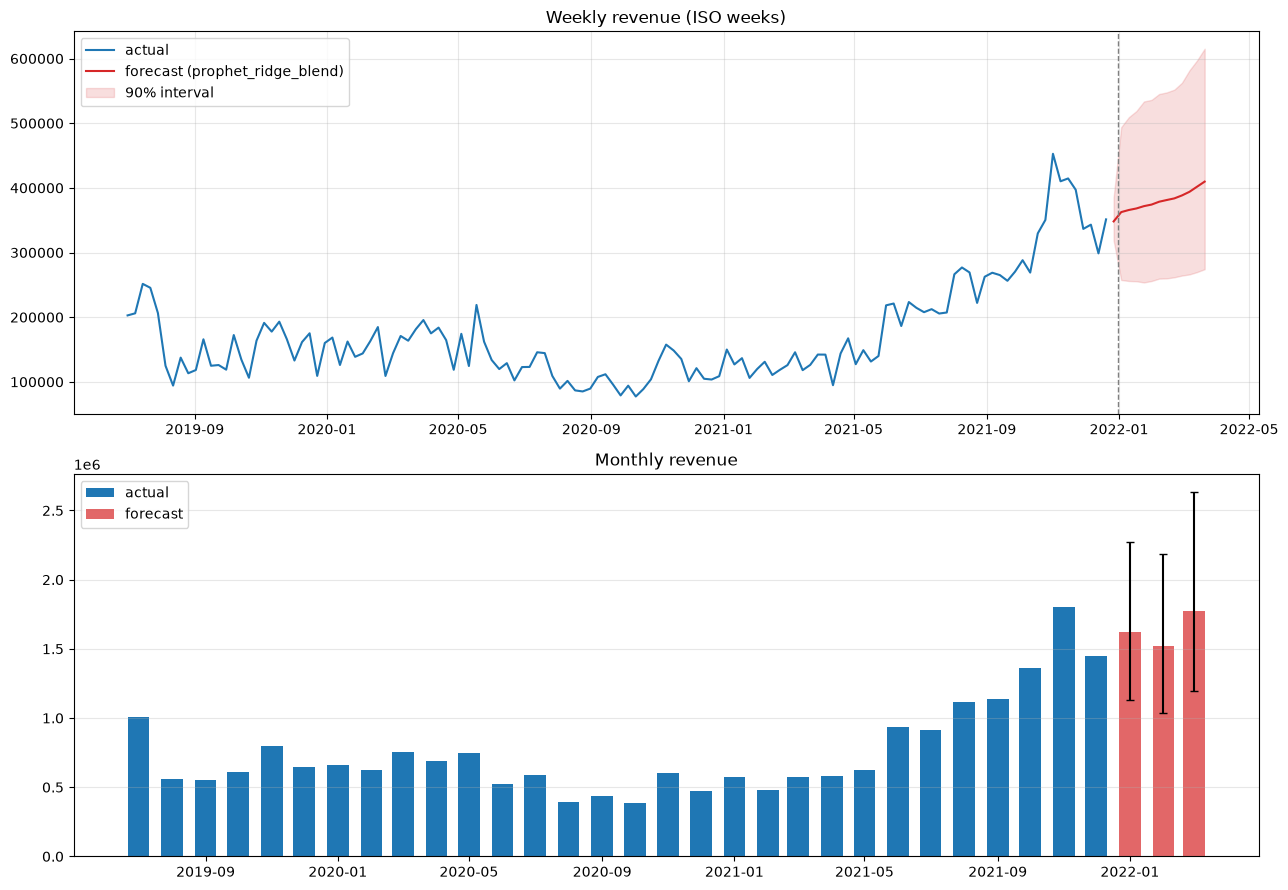

In [10]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9))

w = forecast_weekly.set_index("PeriodStart")
w = w[(w["ActualDays"] + w["ForecastDays"]) == 7]          # complete weeks only (partial edge weeks would show as dips)
hist = w[w["RecordType"] == "actual"]
fut = w[w["ForecastDays"] > 0]   # a mixed week is plotted as actual + forecast days
ax1.plot(hist.index, hist["ActualRevenue"], color="#1f77b4", label="actual")
ax1.plot(fut.index, fut["TotalRevenue"], color="#d62728", label=f"forecast ({CHAMPION})")
ax1.fill_between(fut.index, fut["ActualRevenue"] + fut["ForecastLower"], fut["ActualRevenue"] + fut["ForecastUpper"], color="#d62728", alpha=0.15, label=f"{int(INTERVAL_WIDTH*100)}% interval")
ax1.axvline(LAST_DATE, color="grey", ls="--", lw=1)
ax1.set_title("Weekly revenue (ISO weeks)")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3)

m = forecast_monthly.set_index("PeriodStart")
ax2.bar(m.index, m["ActualRevenue"], width=20, color="#1f77b4", label="actual")
ax2.bar(m.index, m["ForecastRevenue"], width=20, bottom=m["ActualRevenue"], color="#d62728", alpha=0.7, label="forecast")
fut_m = m[m["ForecastDays"] > 0]
ax2.errorbar(fut_m.index, fut_m["ActualRevenue"] + fut_m["ForecastRevenue"],
             yerr=[fut_m["ForecastRevenue"] - fut_m["ForecastLower"], #y1
                   fut_m["ForecastUpper"] - fut_m["ForecastRevenue"]], #y2
                   fmt="none", ecolor="black", #not to plot a line or markers
                   capsize=3) #size (width) of caps
ax2.set_title("Monthly revenue")
ax2.legend(loc="upper left")
ax2.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


## 8. Next steps
* **Pipeline** – add this notebook as a third activity after `Gold_Notebook` (On success). Handle the Prophet / XGBoost / CatBoost dependencies (Environment or `_inlineInstallationEnabled`).
* **Power BI** – `revenue_weekly_gold` / `revenue_monthly_gold` already contain actual + forecast per period (`TotalRevenue` for a continuous line, `ForecastLower/Upper` for the band); `forecast_backtest_gold` gives the model leaderboard (filter `Grain`; `R2`, `DirPrecision` / `DirRecall` / `DirF1` and the summed `TP` / `FP` / `TN` / `FN` are in there too); join `revenue_forecast_history_gold` to `revenue_monthly_gold` on `yyyymm` to report how accurate past forecasts turned out.
* **VS Code** – see `README_VSCode.md`: Fabric extension + *Microsoft Fabric Runtime* kernel to run on Fabric Spark, or a plain Python kernel that reads OneLake directly (`RUN_MODE = local`).
* **Extensions** – per-category forecasts (bikes vs. accessories), holidays/promotions as Prophet regressors or ML features, hyper-parameter search on the ML pipelines, more folds as history grows.
